# 👩‍💻 Weather Data Time Series Forecasting Lab

## 📋 Overview
In this lab, you'll apply time series forecasting techniques to weather data, predicting temperature patterns using ARIMA and Exponential Smoothing models. You'll download historical weather data, prepare it for analysis, implement both forecasting methods, and evaluate their comparative performance. This practical exercise will help you understand when and how to apply different forecasting techniques to extract insights from time series data.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Download and prepare time series weather data for forecasting
- Implement and configure ARIMA models for temperature prediction
- Apply Exponential Smoothing techniques with seasonal components
- Evaluate and compare forecasting methods using standard accuracy metrics
- Visualize time series predictions and interpret the results

## 🚀 Starting Point
Required tools/setup:

- Python 3.x
- Pandas, NumPy, Matplotlib, Statsmodels, and Scikit-learn libraries


## Task 1: Basic checks on the dataset and exploration
**Context:** Weather forecasters need historical data to build reliable prediction models. Check the min and max dates, the data trends and if there are missing values.

**Steps:**

1. Load the data and consider any overall trends:

 - Use `pd.read_csv()` to load data from the file
 - Check if there is any missing data
 - Any hypothesis basis the visual trends?


In [1]:
# Starter code - import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load and explore the GSOD dataset

data = pd.read_csv("niagara_falls_weather_data/weather_data.csv")
print("Shape of Dataset: ", data.shape)
display(data.head())
# Convert DATE to datetime and set as index
data['DATE'] = pd.to_datetime(data['DATE'])
data.set_index('DATE', inplace=True)

Shape of Dataset:  (4006, 28)


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,TEMP,TEMP_ATTRIBUTES,DEWP,DEWP_ATTRIBUTES,...,MXSPD,GUST,MAX,MAX_ATTRIBUTES,MIN,MIN_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNDP,FRSHTT
0,71262599999,2014-01-01,43.191666,-79.171667,97.84,"NIAGARA DISTRICT, CA",16.3,15,7.5,15,...,12.0,999.9,21.2,*,14.0,*,99.99,,999.9,1000
1,71262599999,2014-01-02,43.191666,-79.171667,97.84,"NIAGARA DISTRICT, CA",12.2,15,9.0,15,...,17.1,26.0,15.8,*,10.4,*,99.99,,999.9,1000
2,71262599999,2014-01-03,43.191666,-79.171667,97.84,"NIAGARA DISTRICT, CA",4.9,15,-3.6,15,...,15.9,21.0,10.4,*,1.4,*,99.99,,999.9,1000
3,71262599999,2014-01-04,43.191666,-79.171667,97.84,"NIAGARA DISTRICT, CA",23.2,15,9.3,15,...,26.0,35.9,33.8,*,-0.4,*,0.00,I,999.9,0
4,71262599999,2014-01-05,43.191666,-79.171667,97.84,"NIAGARA DISTRICT, CA",32.7,16,25.6,16,...,17.1,26.0,35.6,*,28.4,*,99.99,,999.9,11000


2. Basic exploration of dataset

In [2]:
# YOUR CODE HERE
print("--------- Information of Dataset ---------")
print(data.info())

print("--------- Summary of Dataset ---------")
display(data.describe().T)

--------- Information of Dataset ---------
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4006 entries, 2014-01-01 to 2024-12-31
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   STATION           4006 non-null   int64  
 1   LATITUDE          4006 non-null   float64
 2   LONGITUDE         4006 non-null   float64
 3   ELEVATION         4006 non-null   float64
 4   NAME              4006 non-null   object 
 5   TEMP              4006 non-null   float64
 6   TEMP_ATTRIBUTES   4006 non-null   int64  
 7   DEWP              4006 non-null   float64
 8   DEWP_ATTRIBUTES   4006 non-null   int64  
 9   SLP               4006 non-null   float64
 10  SLP_ATTRIBUTES    4006 non-null   int64  
 11  STP               4006 non-null   float64
 12  STP_ATTRIBUTES    4006 non-null   int64  
 13  VISIB             4006 non-null   float64
 14  VISIB_ATTRIBUTES  4006 non-null   int64  
 15  WDSP              4006 non-n

,count,mean,std,min,25%,50%,75%,max
STATION,4006.0,7.126260e+10,0.000000e+00,7.126260e+10,7.126260e+10,7.126260e+10,7.126260e+10,7.126260e+10
LATITUDE,4006.0,4.319167e+01,1.058841e-12,4.319167e+01,4.319167e+01,4.319167e+01,4.319167e+01,4.319167e+01
LONGITUDE,4006.0,-7.917167e+01,6.495171e-12,-7.917167e+01,-7.917167e+01,-7.917167e+01,-7.917167e+01,-7.917167e+01
ELEVATION,4006.0,9.784000e+01,6.438321e-12,9.784000e+01,9.784000e+01,9.784000e+01,9.784000e+01,9.784000e+01
TEMP,4006.0,5.213185e+01,1.900730e+01,-3.000000e-01,3.670000e+01,5.220000e+01,6.940000e+01,8.830000e+01
TEMP_ATTRIBUTES,4006.0,1.491513e+01,8.428510e-01,4.000000e+00,1.500000e+01,1.500000e+01,1.500000e+01,1.600000e+01
DEWP,4006.0,4.162102e+01,1.802155e+01,-1.240000e+01,2.832500e+01,4.170000e+01,5.720000e+01,7.680000e+01
DEWP_ATTRIBUTES,4006.0,1.491463e+01,8.428006e-01,4.000000e+00,1.500000e+01,1.500000e+01,1.500000e+01,1.600000e+01
SLP,4006.0,1.016348e+03,7.376395e+00,9.884000e+02,1.011500e+03,1.016200e+03,1.021000e+03,1.044900e+03
SLP_ATTRIBUTES,4006.0,1.479481e+01,1.054724e+00,4.000000e+00,1.500000e+01,1.500000e+01,1.500000e+01,1.600000e+01


💡 **Tip:** Use try-except blocks to handle potential network or file errors when downloading data.

⚙️ **Test Your Work:**

- Verify that the CSV file is loaded as expected
- Check that the file contains data for all years requested


## Task 2: Explore and Visualize the Weather Data
**Context:** Before building forecasting models, data scientists need to understand the patterns and characteristics of their time series data.

**Steps:**

1. Load the downloaded dataset and prepare it for time series analysis:
 - Read the CSV file using pandas
 - Convert the date column to datetime format and set it as the index
 - Handle missing values (GSOD uses 9999.9 to indicate missing data)

In [3]:
# Load and prepare the data
# YOUR CODE HERE
data['TEMP'] = data['TEMP'].replace(9999.9, np.nan)
data = data.dropna(subset=['TEMP'])

2. Create a visualization of the temperature data:
 - Plot the daily mean temperature over time
 - Add appropriate titles, labels, and grid
 - Observe any trends, seasonality, or irregularities

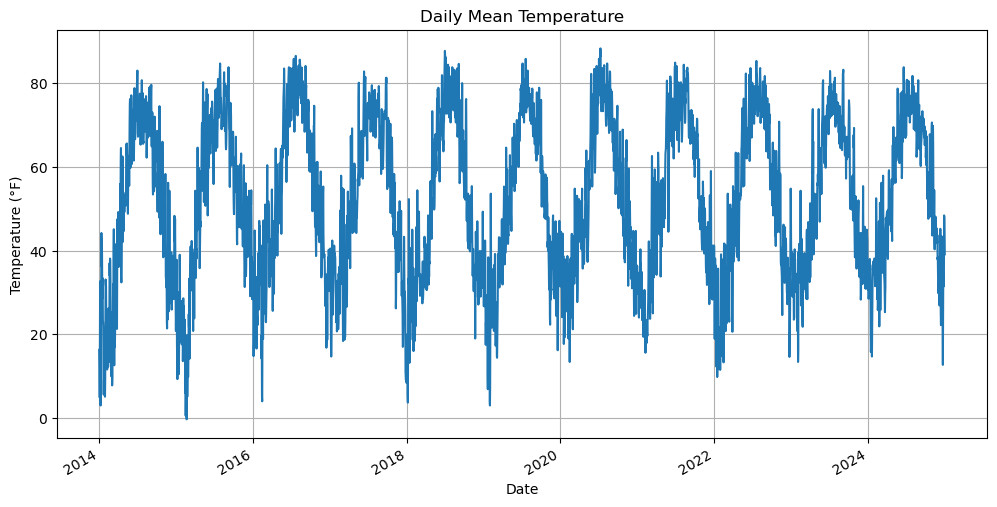

In [4]:
# Visualize the daily temperature data
# YOUR CODE HERE

plt.figure(figsize=(12, 6))
data['TEMP'].plot()
plt.title('Daily Mean Temperature')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

💡 **Tip:** Look for seasonal patterns in temperature data that will inform your forecasting models.

⚙️ **Test Your Work:**

- The plot should show clear temperature patterns over time
- There should be no extreme outliers (like 9999.9) visible in your data

## Task 3: Split Data and Implement ARIMA Forecasting
**Context:** Time series forecasting requires separate training and testing datasets to evaluate model performance properly.

**Steps:**

1. Split the data into training and testing sets:
 - Use 80% of the data for training and 20% for testing
 - Store the length of the test period for later use

In [5]:
# Split data for training and evaluation
# YOUR CODE HERE

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]
test_period = len(test_data)

2. Implement the ARIMA model for temperature forecasting:
 - Import the ARIMA model from statsmodels
 - Set appropriate order parameters (p, d, q)
 - Fit the model to your training data
 - Generate forecasts for the test period

In [6]:
# Implement ARIMA Forecasting
# YOUR CODE HERE
arima_model = ARIMA(train_data['TEMP'], order=(2, 1, 2))  # AR(2), I(1), MA(2)
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=test_period)

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


**💡 Tip**: For ARIMA models, p controls the autoregressive terms, d handles differencing, and q manages moving average terms. Start with (5,1,0) and adjust based on results.

**⚙️ Test Your Work:**

- The ARIMA model should fit without errors
- You should have forecast values for each day in your test period

## Task 4: Implement Exponential Smoothing
**Context:** Exponential Smoothing is another popular forecasting method that can capture both trend and seasonality in time series data.

**Steps:**

1. Apply the Exponential Smoothing model:
 - Import ExponentialSmoothing from statsmodels
 - Configure the model with trend and seasonality components
 - Set an appropriate seasonal period (7 for weekly patterns)
 - Fit the model to your training data
 - Generate forecasts for the test period

In [7]:
# Apply Exponential Smoothing
# YOUR CODE HERE

# For temperature data, seasonal_periods=365 might be more appropriate
# But for a short dataset, we might use 7 for weekly patterns
exp_smooth_model = ExponentialSmoothing(
    train_data['TEMP'],
    trend='add',
    seasonal='add',
    seasonal_periods=365,
    damped_trend=True

)
exp_fit = exp_smooth_model.fit()
exp_forecast = exp_fit.forecast(steps=test_period)

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


💡 **Tip:** For daily temperature data, consider both weekly (7-day) and yearly (365-day) seasonal patterns.

**⚙️ Test Your Work:**

- The Exponential Smoothing model should fit without errors
- You should have forecast values for each day in your test period

## Task 5: Visualize and Compare Forecast Results
**Context:** Visual comparison of forecasts helps analysts determine which model best captures the patterns in the data.

**Steps:**

1. Create a combined plot showing both forecasting methods:
 - Plot the training data, actual test data, and both forecasts
 - Use different line styles to distinguish between data series
 - Add appropriate labels, title, and legend


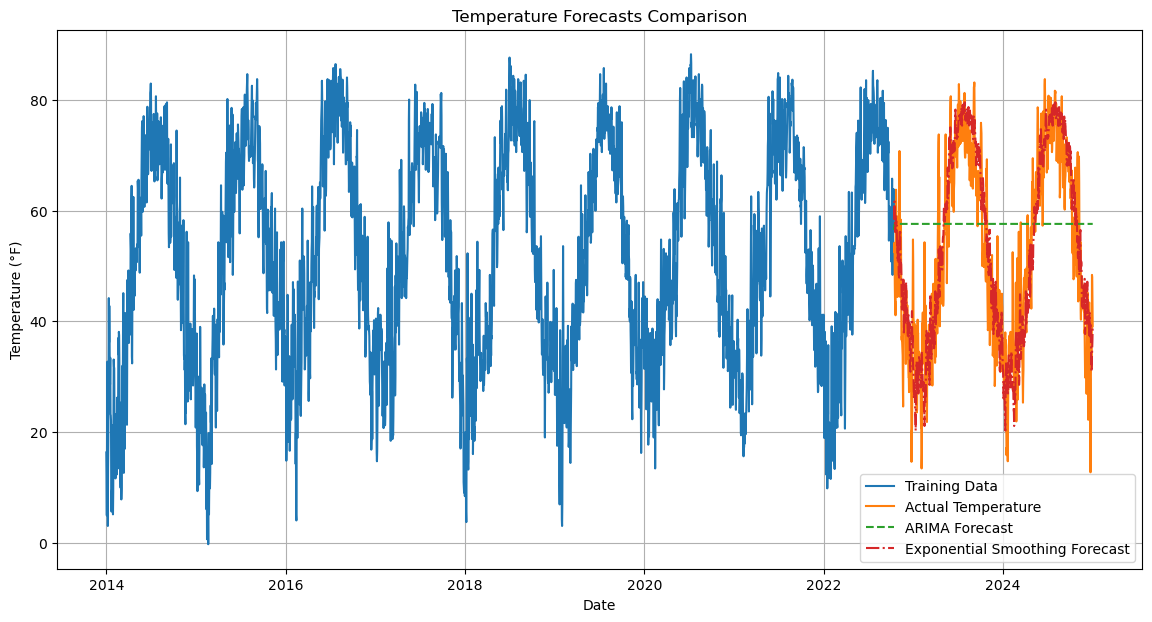

In [8]:
# Create a combined visualization of both forecasts
# YOUR CODE HERE

plt.figure(figsize=(14, 7))
plt.plot(train_data['TEMP'], label='Training Data')
plt.plot(test_data['TEMP'], label='Actual Temperature')
plt.plot(test_data.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.plot(test_data.index, exp_forecast, label='Exponential Smoothing Forecast', linestyle='-.')
plt.title('Temperature Forecasts Comparison')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

2. Generate individual plots for each forecasting method:
 - Create separate visualizations for ARIMA and Exponential Smoothing
 - Include training data, actual test data, and forecast values
 - Add appropriate formatting and labels

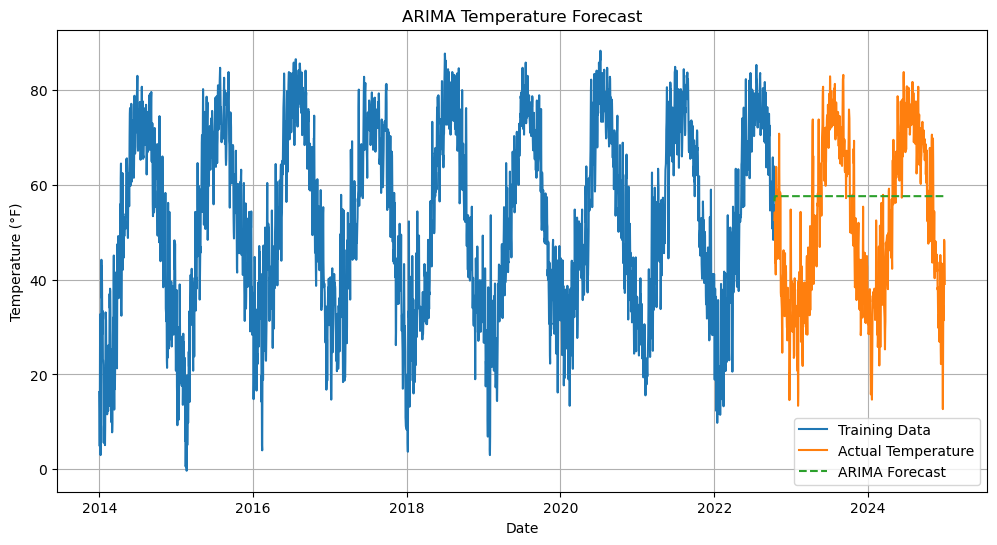

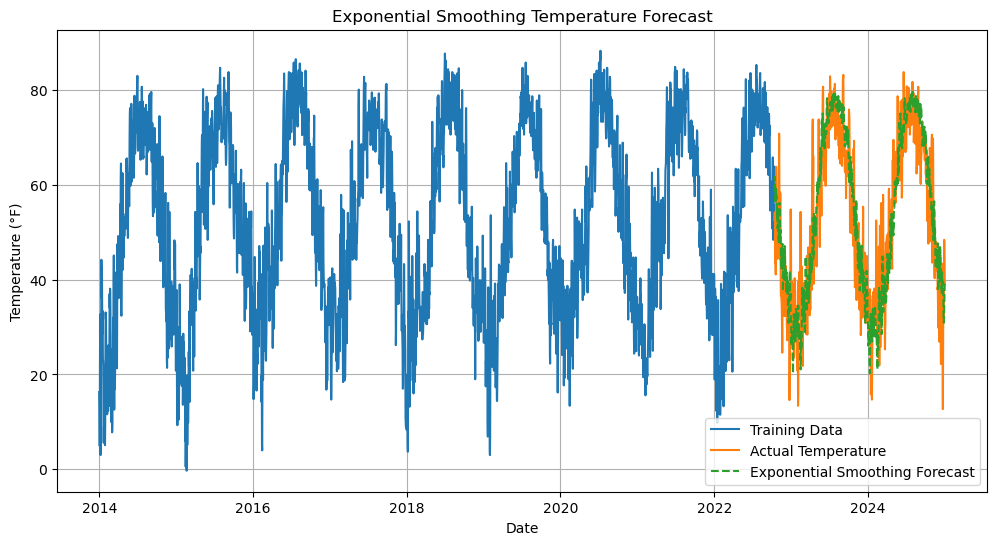

In [9]:
# Create individual plots for each forecasting method
# YOUR CODE HERE

# Individual model plots
plt.figure(figsize=(12, 6))
plt.plot(train_data['TEMP'], label='Training Data')
plt.plot(test_data['TEMP'], label='Actual Temperature')
plt.plot(test_data.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Temperature Forecast')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(train_data['TEMP'], label='Training Data')
plt.plot(test_data['TEMP'], label='Actual Temperature')
plt.plot(test_data.index, exp_forecast, label='Exponential Smoothing Forecast', linestyle='--')
plt.title('Exponential Smoothing Temperature Forecast')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

**💡 Tip:** Use different colors and line styles to clearly differentiate between actual values and predictions.

**⚙️ Test Your Work:**

- The plots should clearly show the relationship between actual and predicted values
- Legends should correctly identify each data series

## Task 6: Evaluate Forecast Accuracy
**Context:** Quantitative metrics help analysts objectively compare the accuracy of different forecasting methods.

**Steps:**

1. Calculate error metrics for both forecasting methods:
 - Compute Mean Absolute Error (MAE)
 - Calculate Mean Squared Error (MSE)
 - Determine Root Mean Squared Error (RMSE)
 - Compare the results between ARIMA and Exponential Smoothing

In [10]:
# Evaluate forecast accuracy
# YOUR CODE HERE

# Evaluate Forecast Accuracy
print('ARIMA MAE:', mean_absolute_error(test_data['TEMP'], arima_forecast))
print('Exp. Smoothing MAE:', mean_absolute_error(test_data['TEMP'], exp_forecast))
print('ARIMA MSE:', mean_squared_error(test_data['TEMP'], arima_forecast))
print('Exp. Smoothing MSE:', mean_squared_error(test_data['TEMP'], exp_forecast))
print('ARIMA RMSE:', np.sqrt(mean_squared_error(test_data['TEMP'], arima_forecast)))
print('Exp. Smoothing RMSE:', np.sqrt(mean_squared_error(test_data['TEMP'], exp_forecast)))

ARIMA MAE: 15.277324166276593
Exp. Smoothing MAE: 6.47883792440121
ARIMA MSE: 308.79980533264853
Exp. Smoothing MSE: 67.69486072020915
ARIMA RMSE: 17.572700570277995
Exp. Smoothing RMSE: 8.22768866208543


2. Analyze the results and determine which model performed better for this dataset.

**💡 Tip:** Lower values for MAE, MSE, and RMSE indicate better forecast accuracy.

**⚙️ Test Your Work:**

- You should have numerical values for each error metric
- The metrics should allow for clear comparison between models

## ✅ Success Checklist

- Successfully downloaded and combined weather data from multiple years
- Properly prepared and visualized the time series data
- Split the data appropriately for training and testing
- Implemented and configured an ARIMA model for temperature forecasting
- Applied Exponential Smoothing with seasonal components
- Created clear visualizations comparing actual values with forecasts
- Calculated and compared accuracy metrics for both forecasting methods
- Program runs without errors

## 🔍 Common Issues & Solutions

**Problem:** CSV file not downloading properly. 

**Solution:** Check your internet connection and verify the station ID and URL format.

**Problem:** ARIMA model throwing convergence errors.

**Solution:** Try different order parameters (p,d,q) or use auto_arima from pmdarima package to find optimal parameters.

**Problem:** Forecasts show unrealistic temperature values.

**Solution:** Ensure proper data cleaning, especially removing outliers and handling missing values correctly.

## 🔑 Key Points

- Time series forecasting requires proper data preparation, including handling missing values and setting the date as index
- ARIMA models are useful for capturing autocorrelations in time series data
- Exponential Smoothing excels at capturing trend and seasonality components
- Visualization is essential for understanding time series patterns and forecast performance
- Multiple evaluation metrics should be used to compare forecasting methods objectively

## 💻Exemplar Solution
After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches.
Reflect on what you can learn from the exemplar solution to improve your coding skills.
Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.
Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
# Starter code - import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load and explore the GSOD dataset

data = pd.read_csv("niagara_falls_weather_data/weather_data.csv")
print(data.head())
# Convert DATE to datetime and set as index
data['DATE'] = pd.to_datetime(data['DATE'])
data.set_index('DATE', inplace=True)

# Let's use the TEMP (mean temperature) column for forecasting
# First, let's clean the data - GSOD uses 9999.9 for missing values
data['TEMP'] = data['TEMP'].replace(9999.9, np.nan)
data = data.dropna(subset=['TEMP'])

# Exploratory visualization
plt.figure(figsize=(12, 6))
data['TEMP'].plot()
plt.title('Daily Mean Temperature')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

# Split data for training and evaluation
# Let's use 80% for training, 20% for testing
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]
test_period = len(test_data)

# Implement ARIMA Forecasting - adjust order parameters as needed for temperature data
arima_model = ARIMA(train_data['TEMP'], order=(2, 1, 2))  # AR(2), I(1), MA(2)
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=test_period)

# Apply Exponential Smoothing
# For temperature data, seasonal_periods=365 might be more appropriate
# But for a short dataset, we might use 7 for weekly patterns
exp_smooth_model = ExponentialSmoothing(
    train_data['TEMP'],
    trend='add',
    seasonal='add',
    seasonal_periods=365,
    damped_trend=True

)
exp_fit = exp_smooth_model.fit()
exp_forecast = exp_fit.forecast(steps=test_period)

# Visualize forecasts against actual data
plt.figure(figsize=(14, 7))
plt.plot(train_data['TEMP'], label='Training Data')
plt.plot(test_data['TEMP'], label='Actual Temperature')
plt.plot(test_data.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.plot(test_data.index, exp_forecast, label='Exponential Smoothing Forecast', linestyle='-.')
plt.title('Temperature Forecasts Comparison')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

# Individual model plots
plt.figure(figsize=(12, 6))
plt.plot(train_data['TEMP'], label='Training Data')
plt.plot(test_data['TEMP'], label='Actual Temperature')
plt.plot(test_data.index, arima_forecast, label='ARIMA Forecast', linestyle='--')
plt.title('ARIMA Temperature Forecast')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(train_data['TEMP'], label='Training Data')
plt.plot(test_data['TEMP'], label='Actual Temperature')
plt.plot(test_data.index, exp_forecast, label='Exponential Smoothing Forecast', linestyle='--')
plt.title('Exponential Smoothing Temperature Forecast')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate Forecast Accuracy
print('ARIMA MAE:', mean_absolute_error(test_data['TEMP'], arima_forecast))
print('Exp. Smoothing MAE:', mean_absolute_error(test_data['TEMP'], exp_forecast))
print('ARIMA MSE:', mean_squared_error(test_data['TEMP'], arima_forecast))
print('Exp. Smoothing MSE:', mean_squared_error(test_data['TEMP'], exp_forecast))
print('ARIMA RMSE:', np.sqrt(mean_squared_error(test_data['TEMP'], arima_forecast)))
print('Exp. Smoothing RMSE:', np.sqrt(mean_squared_error(test_data['TEMP'], exp_forecast)))
  ```